# 03_rl_training_and_eval.ipynb
_SERAPH — load_qm9, dqn_agent, acquisition_env, train_dqn, evaluate_dqn_

#Setup Stuff

In [3]:
import sys; sys.path.insert(0, '..')

import torch
#!pip install torch-geometric    #Couldn't get code to work w/o this, but can comment out once loaded in colab
import numpy as np
import random
import os
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

#from models.dqn_agent import DQNAgent
#from environment.acquisition_env import AcquisitionEnv
#from data.load_qm9 import load_qm9

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cpu


##Configuration - config.py

In [4]:
%%writefile config.py
#make import config work for all other cells
# config.py — all SERAPH hyperparameters in one place
# ─────────────────────────────────────────────────────────────────────────────

# ── Dataset ───────────────────────────────────────────────────────────────────
DATA_ROOT      = "./data"          # QM9 will download here on first run
TARGET_PROP    = "gap"             # which QM9 property to predict
#   Options: mu, alpha, homo, lumo, gap, r2, zpve, u0, u298, h298,
#            g298, cv, u0_atom, u298_atom, h298_atom, g298_atom, a, b, c

NUM_FEATURES   = 19                # total acquirable properties in QM9
TRAIN_FRAC     = 0.8
VAL_FRAC       = 0.1
# (remainder is test)

# ── RL Environment ────────────────────────────────────────────────────────────
LAMBDA         = 0.1               # cost-accuracy tradeoff (sweep for ablation)
MAX_STEPS      = NUM_FEATURES      # episode ends when all features acquired
                                   # (agent can stop early via terminal action)

# ── DQN Agent ─────────────────────────────────────────────────────────────────
HIDDEN_DIM     = 128               # FC layer width in policy network
NUM_LAYERS     = 2                 # number of hidden layers
LR             = 1e-3
GAMMA          = 0.99              # discount factor
EPS_START      = 1.0               # ε-greedy exploration start
EPS_END        = 0.05
EPS_DECAY      = 5000              # steps over which ε decays
REPLAY_SIZE    = 10_000            # replay buffer capacity
BATCH_SIZE     = 64
TARGET_UPDATE  = 500               # steps between target-network syncs

# ── Predictor MLP ─────────────────────────────────────────────────────────────
PRED_HIDDEN    = 64 #was 64
PRED_LAYERS    = 2
PRED_LR        = 3e-4
PRED_EPOCHS    = 50                # pre-training epochs for the predictor

# ── Training ──────────────────────────────────────────────────────────────────
NUM_EPISODES   = 5_000
SEED           = 42
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

# ── Checkpointing ─────────────────────────────────────────────────────────────
CHECKPOINT_DIR = "./checkpoints"
RESULTS_DIR    = "./results"

# ── Ablation λ sweep ──────────────────────────────────────────────────────────
LAMBDA_SWEEP   = [0.01, 0.05, 0.1, 0.2, 0.5]


Writing config.py


## Data Loading - data/load_qm9.py

In [5]:
"""
data/load_qm9.py
────────────────
Loads the QM9 dataset via PyTorch Geometric, normalizes the 19 quantum-chemical
properties, and returns train / val / test splits as PyG Data loaders.

Usage
-----
    from data.load_qm9 import load_qm9, PROPERTY_NAMES

    train_loader, val_loader, test_loader, stats = load_qm9()

The returned `stats` dict contains per-property mean and std so the RL
environment and predictor can un-normalize predictions for interpretability.
"""

import os
import sys
#sys.path.insert(0, os.path.join(os.path.dirname(__file__), ".."))

import torch
from torch.utils.data import random_split
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import NormalizeFeatures

import config

# ── Property index → human-readable name ──────────────────────────────────────
# QM9 exposes 19 molecular properties as target columns (data.y[:, idx]).
# Index order follows the original QM9 paper (Ramakrishnan et al. 2014).
PROPERTY_NAMES = [
    "mu",       # 0  Dipole moment (D)
    "alpha",    # 1  Isotropic polarizability (a₀³)
    "homo",     # 2  HOMO energy (Ha)
    "lumo",     # 3  LUMO energy (Ha)
    "gap",      # 4  HOMO-LUMO gap (Ha)
    "r2",       # 5  Electronic spatial extent (a₀²)
    "zpve",     # 6  Zero-point vibrational energy (Ha)
    "u0",       # 7  Internal energy at 0 K (Ha)
    "u298",     # 8  Internal energy at 298.15 K (Ha)
    "h298",     # 9  Enthalpy at 298.15 K (Ha)
    "g298",     # 10 Free energy at 298.15 K (Ha)
    "cv",       # 11 Heat capacity at 298.15 K (cal/mol·K)
    "u0_atom",  # 12 Atomisation energy at 0 K (Ha)
    "u298_atom",# 13 Atomisation energy at 298.15 K (Ha)
    "h298_atom",# 14 Atomisation enthalpy at 298.15 K (Ha)
    "g298_atom",# 15 Atomisation free energy at 298.15 K (Ha)
    "a",        # 16 Rotational constant A (GHz)
    "b",        # 17 Rotational constant B (GHz)
    "c",        # 18 Rotational constant C (GHz)
]

# Map string name → column index (used by config.TARGET_PROP)
PROPERTY_INDEX = {name: idx for idx, name in enumerate(PROPERTY_NAMES)}

TARGET_IDX = PROPERTY_INDEX[config.TARGET_PROP]


# ── Main loader ────────────────────────────────────────────────────────────────

def load_qm9(
    root: str = config.DATA_ROOT,
    target: str = config.TARGET_PROP,
    batch_size: int = config.BATCH_SIZE,
    train_frac: float = config.TRAIN_FRAC,
    val_frac: float = config.VAL_FRAC,
    seed: int = config.SEED,
    num_workers: int = 0,
) -> tuple[DataLoader, DataLoader, DataLoader, dict]:
    """
    Download (first run only) and return QM9 data loaders.

    Parameters
    ----------
    root        : directory where QM9 raw/processed files are cached
    target      : property name to predict (must be in PROPERTY_NAMES)
    batch_size  : samples per mini-batch
    train_frac  : fraction of dataset used for training
    val_frac    : fraction used for validation (remainder = test)
    seed        : random seed for reproducible splits
    num_workers : DataLoader worker processes (keep 0 on MPS/macOS)

    Returns
    -------
    train_loader, val_loader, test_loader, stats
        stats = {"mean": Tensor(19,), "std": Tensor(19,), "target_idx": int}
    """
    if target not in PROPERTY_INDEX:
        raise ValueError(
            f"Unknown target '{target}'. Choose from: {list(PROPERTY_INDEX)}"
        )

    target_idx = PROPERTY_INDEX[target]
    print(f"[QM9] Loading dataset from '{root}' …")
    print(f"[QM9] Target property: '{target}' (column {target_idx})")

    # PyG downloads & caches QM9 automatically on first call (~1.7 GB)
    dataset = QM9(root=root)

    n_total = len(dataset)
    n_train = int(n_total * train_frac)
    n_val   = int(n_total * val_frac)
    n_test  = n_total - n_train - n_val

    print(f"[QM9] {n_total:,} molecules → "
          f"train {n_train:,} / val {n_val:,} / test {n_test:,}")

    # Reproducible random split
    generator = torch.Generator().manual_seed(seed)
    train_set, val_set, test_set = random_split(
        dataset, [n_train, n_val, n_test], generator=generator
    )

    # ── Compute normalisation statistics on training set only ─────────────────
    # Collect all 19 properties from the training split
    all_y = torch.stack([dataset[i].y.squeeze() for i in train_set.indices])
    # all_y shape: (n_train, 19)

    mean = all_y.mean(dim=0)   # (19,)
    std  = all_y.std(dim=0)    # (19,)
    std  = std.clamp(min=1e-8) # avoid division by zero for constant features

    print(f"[QM9] Target '{target}' — "
          f"mean: {mean[target_idx]:.4f}, std: {std[target_idx]:.4f}")

    # Inject normalised targets into each split via a wrapper
    train_set = _NormalisedSubset(train_set, mean, std)
    val_set   = _NormalisedSubset(val_set,   mean, std)
    test_set  = _NormalisedSubset(test_set,  mean, std)

    # pin_memory speeds up CPU→GPU transfers; not supported on MPS
    pin = (config.DEVICE == "cuda")

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin,
    )
    val_loader = DataLoader(
        val_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin,
    )
    test_loader = DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin,
    )

    stats = {
        "mean":       mean,        # (19,) — use to un-normalise predictions
        "std":        std,         # (19,)
        "target_idx": target_idx,  # int
        "target":     target,      # str
    }

    return train_loader, val_loader, test_loader, stats


# ── Normalisation wrapper ──────────────────────────────────────────────────────

class _NormalisedSubset(torch.utils.data.Dataset):
    """
    Wraps a Subset and returns a copy of each Data object whose `.y` tensor
    has been standardised: y_norm = (y - mean) / std.

    The original un-normalised values are preserved as `.y_raw` for logging.
    """

    def __init__(self, subset, mean: torch.Tensor, std: torch.Tensor):
        self.subset = subset
        self.mean   = mean
        self.std    = std

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        data        = self.subset[idx].clone()
        data.y_raw  = data.y.clone()                    # (1, 19) un-normalised
        data.y      = (data.y - self.mean) / self.std   # (1, 19) normalised
        return data


# ── Convenience: extract flat property matrix ─────────────────────────────────

def extract_property_matrix(loader: DataLoader) -> torch.Tensor:
    """
    Returns a (N, 19) tensor of *normalised* properties for every molecule in
    the loader. Useful for quick analysis or feeding the RL environment directly.
    """
    ys = []
    for batch in loader:
        ys.append(batch.y)         # shape: (batch_size, 19)
    return torch.cat(ys, dim=0)


# ── Quick smoke test ───────────────────────────────────────────────────────────

if __name__ == "__main__":
    train_loader, val_loader, test_loader, stats = load_qm9()

    # Grab one batch and print shapes
    batch = next(iter(train_loader))
    print("\n── Sample batch ──")
    print(f"  Nodes (atom features) : {batch.x.shape}")
    print(f"  Edge index            : {batch.edge_index.shape}")
    print(f"  Properties (y)        : {batch.y.shape}")
    print(f"  Properties (y_raw)    : {batch.y_raw.shape}")
    print(f"  Batch vector          : {batch.batch.shape}")

    print("\n── Normalisation stats ──")
    for i, name in enumerate(PROPERTY_NAMES):
        print(f"  {name:<12} mean={stats['mean'][i]:+.4f}  std={stats['std'][i]:.4f}")

    print("\n✅  load_qm9.py working correctly.")

cpu
[QM9] Loading dataset from './data' …
[QM9] Target property: 'gap' (column 4)


Extracting data/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


[QM9] 130,831 molecules → train 104,664 / val 13,083 / test 13,084
[QM9] Target 'gap' — mean: 6.8574, std: 1.2826

── Sample batch ──
  Nodes (atom features) : torch.Size([1167, 11])
  Edge index            : torch.Size([2, 2396])
  Properties (y)        : torch.Size([64, 19])
  Properties (y_raw)    : torch.Size([64, 19])
  Batch vector          : torch.Size([1167])

── Normalisation stats ──
  mu           mean=+2.6738  std=1.5057
  alpha        mean=+75.2767  std=8.1808
  homo         mean=-6.5370  std=0.5982
  lumo         mean=+0.3204  std=1.2731
  gap          mean=+6.8574  std=1.2826
  r2           mean=+1189.7844  std=280.6400
  zpve         mean=+4.0563  std=0.9012
  u0           mean=-11180.2744  std=1085.7927
  u298         mean=-11180.0449  std=1085.7869
  h298         mean=-11180.0195  std=1085.7869
  g298         mean=-11181.1846  std=1085.8063
  cv           mean=+31.6176  std=4.0636
  u0_atom      mean=-76.1065  std=10.3181
  u298_atom    mean=-76.5709  std=10.4094
  h2

##Acquisition Environment - acquisition_env.py

In [6]:
"""
environment/acquisition_env.py
───────────────────────────────
The RL environment for SERAPH.

The agent interacts with one molecule per episode, sequentially deciding
which of the 19 QM9 properties to "acquire" (observe). After each acquisition
the predictor re-runs on the newly revealed features and the reward is:

    reward = Δaccuracy − λ × cost

where Δaccuracy is the reduction in MSE vs the previous step, cost = 1 per
feature acquired, and λ is the accuracy/cost tradeoff from config.py.

Interface mirrors OpenAI Gym so it is compatible with standard RL libraries:

    env = AcquisitionEnv(molecules, stats, predictor)
    state = env.reset()
    state, reward, done, info = env.step(action)

State
-----
A dict with two keys:
    "mask"   : FloatTensor (19,) — 1 if property i has been acquired, else 0
    "values" : FloatTensor (19,) — normalised property values where acquired,
                                   0.0 where not yet acquired

The DQN policy network receives torch.cat([mask, values]) → dim 38 input.
"""

import os
import sys
#sys.path.insert(0, os.path.join(os.path.dirname(__file__), ".."))

import random
import torch
import numpy as np
from typing import Optional


import importlib

if "config" in sys.modules:
    del sys.modules["config"]

import config
importlib.reload(config)

print(config.__file__)
print(config.DEVICE)


#from data.load_qm9 import PROPERTY_NAMES, PROPERTY_INDEX


# ── Environment ────────────────────────────────────────────────────────────────

class AcquisitionEnv:
    """
    Sequential feature acquisition environment for QM9 molecules.

    Parameters
    ----------
    molecules : list of (property_vector,) tuples — each is a FloatTensor (19,)
                of *normalised* property values for one molecule.
                Build this from the DataLoaders returned by load_qm9.
    stats     : dict returned by load_qm9() — contains mean, std, target_idx.
    predictor : a models.Predictor instance (or None for random baseline).
                Must implement predictor.predict(values, mask) → scalar.
    lam       : λ, the cost penalty per feature acquired. Defaults to
                config.LAMBDA. Sweep this for ablation studies.
    max_steps : maximum acquisitions per episode (defaults to config.NUM_FEATURES
                so the agent can acquire everything if it wants to).
    device    : torch device string ("mps", "cuda", or "cpu").
    seed      : optional random seed for reproducibility.
    """

    # Number of acquirable features
    N_FEATURES = config.NUM_FEATURES  # 19

    # Flat state dimension fed to the DQN: mask (19) + values (19)
    STATE_DIM = N_FEATURES * 2        # 38

    def __init__(
        self,
        molecules: list,
        stats: dict,
        predictor,
        lam: float = config.LAMBDA,
        max_steps: int = config.NUM_FEATURES,
        device: str = config.DEVICE,
        seed: Optional[int] = config.SEED,
    ):
        self.molecules  = molecules
        self.stats      = stats
        self.predictor  = predictor
        self.lam        = lam
        self.max_steps  = max_steps
        self.device     = torch.device(device)
        self.target_idx = stats["target_idx"]

        print(config.__file__)
        print(config.DEVICE)
        print(self.device)

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)

        # Episode state (populated by reset())
        self._molecule   : Optional[torch.Tensor] = None  # (19,) normalised
        self._mask       : Optional[torch.Tensor] = None  # (19,) binary
        self._values     : Optional[torch.Tensor] = None  # (19,) masked values
        self._prev_mse   : float = float("inf")
        self._step       : int   = 0

        # Tracking for info dict
        self._acquired_order : list[int] = []

    # ── Core interface ─────────────────────────────────────────────────────────

    def reset(self, molecule_idx: Optional[int] = None) -> torch.Tensor:
        """
        Start a new episode.

        Parameters
        ----------
        molecule_idx : index into self.molecules. If None, sampled randomly.

        Returns
        -------
        state : FloatTensor (STATE_DIM,) = cat([mask, values])
        """
        if molecule_idx is None:
            molecule_idx = random.randrange(len(self.molecules))

        self._molecule = self.molecules[molecule_idx].to(self.device)  # (19,)
        self._mask     = torch.zeros(self.N_FEATURES, device=self.device)
        self._values   = torch.zeros(self.N_FEATURES, device=self.device)
        self._step     = 0
        self._acquired_order = []

        # Baseline MSE with zero features acquired
        self._prev_mse = self._compute_mse()

        return self._get_state()

    def step(self, action: int) -> tuple[torch.Tensor, float, bool, dict]:
        """
        Acquire the property at index `action`.

        Parameters
        ----------
        action : int in [0, N_FEATURES). Must not already be acquired.

        Returns
        -------
        state  : FloatTensor (STATE_DIM,) — updated state after acquisition
        reward : float
        done   : bool — True if episode should end
        info   : dict — diagnostic info (mse, acquired_order, etc.)
        """
        assert 0 <= action < self.N_FEATURES, \
            f"Invalid action {action} — must be in [0, {self.N_FEATURES})"
        assert self._mask[action] == 0, \
            f"Property {action} ({PROPERTY_NAMES[action]}) already acquired"
        assert self._molecule is not None, \
            "Call reset() before step()"

        # ── Acquire the chosen property ────────────────────────────────────────
        self._mask[action]   = 1.0
        self._values[action] = self._molecule[action]
        self._acquired_order.append(action)
        self._step += 1

        # ── Compute reward ─────────────────────────────────────────────────────
        new_mse    = self._compute_mse()
        delta_acc  = self._prev_mse - new_mse   # positive = improvement
        cost       = 1.0                        # one unit per feature
        reward     = delta_acc - self.lam * cost
        self._prev_mse = new_mse

        # ── Check termination ──────────────────────────────────────────────────
        all_acquired = self._mask.sum().item() == self.N_FEATURES
        max_reached  = self._step >= self.max_steps
        done         = all_acquired or max_reached

        info = {
            "mse"            : new_mse,
            "delta_acc"      : delta_acc,
            "step"           : self._step,
            "n_acquired"     : int(self._mask.sum().item()),
            "acquired_order" : list(self._acquired_order),
            "acquired_names" : [PROPERTY_NAMES[i] for i in self._acquired_order],
        }

        return self._get_state(), reward, done, info

    # ── Legal action masking ───────────────────────────────────────────────────

    def legal_actions(self) -> list[int]:
        """Return indices of properties not yet acquired this episode."""
        return [i for i in range(self.N_FEATURES) if self._mask[i] == 0]

    def legal_action_mask(self) -> torch.Tensor:
        """
        Returns a BoolTensor (N_FEATURES,) where True = not yet acquired.
        Feed this to the DQN to zero-out Q-values for illegal actions before
        taking the argmax.
        """
        return self._mask == 0  # True where not acquired

    # ── Internal helpers ───────────────────────────────────────────────────────

    def _get_state(self) -> torch.Tensor:
        """Flat state vector: cat([mask, values]) → (STATE_DIM,)."""
        return torch.cat([self._mask, self._values])  # (38,)

    def _compute_mse(self) -> float:
        """
        Ask the predictor for a target estimate given current observations,
        then return MSE against the true (normalised) target.

        If no predictor is attached (predictor=None), returns the variance of
        the target across the training set as a fixed baseline MSE.
        """
        true_target = self._molecule[self.target_idx].item()

        if self.predictor is None:
            # No predictor: treat baseline MSE as 1.0 (normalised variance)
            return 1.0

        with torch.no_grad():
            pred = self.predictor.predict(self._values, self._mask)

        mse = (pred.item() - true_target) ** 2
        return mse

    # ── Utility ────────────────────────────────────────────────────────────────

    def render(self):
        """Print a simple text summary of the current episode state."""
        if self._molecule is None:
            print("Environment not initialised — call reset() first.")
            return

        print(f"\n── Episode step {self._step} ──")
        print(f"  Target property : {PROPERTY_NAMES[self.target_idx]}")
        print(f"  Features acquired ({int(self._mask.sum())}/{self.N_FEATURES}):")
        for i in self._acquired_order:
            val_norm = self._values[i].item()
            val_real = val_norm * self.stats["std"][i].item() \
                     + self.stats["mean"][i].item()
            print(f"    [{i:>2}] {PROPERTY_NAMES[i]:<12} "
                  f"normalised={val_norm:+.4f}  real={val_real:+.4f}")
        if self._mask.sum() < self.N_FEATURES:
            remaining = [PROPERTY_NAMES[i] for i in self.legal_actions()]
            print(f"  Remaining : {remaining}")
        print(f"  Current MSE : {self._prev_mse:.6f}")


# ── Dataset helper: build molecule list from DataLoader ───────────────────────

def build_molecule_list(loader) -> list[torch.Tensor]:
    """
    Flatten a PyG DataLoader into a plain list of (19,) property tensors.
    This is the format AcquisitionEnv expects.

    Usage
    -----
        from data.load_qm9 import load_qm9
        from environment.acquisition_env import build_molecule_list

        train_loader, val_loader, test_loader, stats = load_qm9()
        molecules = build_molecule_list(train_loader)
        env = AcquisitionEnv(molecules, stats, predictor=None)
    """
    molecules = []
    for batch in loader:
        # batch.y shape: (batch_size, 19) — normalised by _NormalisedSubset
        for y in batch.y:
            molecules.append(y.squeeze().float())  # (19,)
    print(f"[AcquisitionEnv] Built molecule list: {len(molecules):,} molecules")
    return molecules


# ── Smoke test ─────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    #from data.load_qm9 import load_qm9

    print("Loading QM9 …")
    train_loader, val_loader, test_loader, stats = load_qm9(batch_size=256)
    molecules = build_molecule_list(train_loader)

    print("\nInitialising environment (no predictor — random baseline) …")
    env = AcquisitionEnv(molecules, stats, predictor=None, seed=42)

    # Run one full episode with random actions
    state = env.reset(molecule_idx=0)
    print(f"\nInitial state shape : {state.shape}")
    print(f"STATE_DIM           : {AcquisitionEnv.STATE_DIM}")

    total_reward = 0.0
    done = False
    while not done:
        action = random.choice(env.legal_actions())
        state, reward, done, info = env.step(action)
        total_reward += reward
        print(f"  step {info['step']:>2} | acquired '{PROPERTY_NAMES[action]:<12}' "
              f"| reward={reward:+.5f} | mse={info['mse']:.5f}")

    print(f"\nEpisode complete.")
    print(f"  Total reward    : {total_reward:.4f}")
    print(f"  Features used   : {info['n_acquired']}/{config.NUM_FEATURES}")
    print(f"  Acquisition order: {info['acquired_names']}")
    env.render()

    # Verify legal action masking works
    env.reset()
    env.step(0)
    env.step(1)
    mask = env.legal_action_mask()
    assert mask[0] == False and mask[1] == False and mask[2] == True
    print("\n✅  acquisition_env.py working correctly.")


cpu
cpu
/content/config.py
cpu
Loading QM9 …
[QM9] Loading dataset from './data' …
[QM9] Target property: 'gap' (column 4)
[QM9] 130,831 molecules → train 104,664 / val 13,083 / test 13,084
[QM9] Target 'gap' — mean: 6.8574, std: 1.2826
[AcquisitionEnv] Built molecule list: 104,664 molecules

Initialising environment (no predictor — random baseline) …
/content/config.py
cpu
cpu

Initial state shape : torch.Size([38])
STATE_DIM           : 38
  step  1 | acquired 'lumo        ' | reward=-0.10000 | mse=1.00000
  step  2 | acquired 'mu          ' | reward=-0.10000 | mse=1.00000
  step  3 | acquired 'g298        ' | reward=-0.10000 | mse=1.00000
  step  4 | acquired 'h298        ' | reward=-0.10000 | mse=1.00000
  step  5 | acquired 'r2          ' | reward=-0.10000 | mse=1.00000
  step  6 | acquired 'gap         ' | reward=-0.10000 | mse=1.00000
  step  7 | acquired 'b           ' | reward=-0.10000 | mse=1.00000
  step  8 | acquired 'homo        ' | reward=-0.10000 | mse=1.00000
  step  9 

##Predictor - predictor.py

In [7]:
"""
models/predictor.py
────────────────────
The predictor MLP for SERAPH.

Takes a masked property vector (19 values, zeroed where not yet acquired)
and a binary acquisition mask (19 flags), and predicts the normalised target
property (e.g. HOMO-LUMO gap).

The predictor serves two roles in SERAPH:

  1. INSIDE the RL environment — called after every acquisition to compute
     the accuracy gain that drives the reward signal. Must be fast.

  2. AS a standalone baseline — trained on all 19 features (mask all ones)
     to give the upper-bound "full information" performance.

Architecture
------------
Input  : cat([mask, values])  →  dim 38
Hidden : N fully-connected layers with ReLU + optional Dropout
Output : scalar prediction of the normalised target

The 38-dim input mirrors the state vector in acquisition_env.py so the
predictor can be slotted directly into the environment without reshaping.
"""

import os
import sys
#sys.path.insert(0, os.path.join(os.path.dirname(__file__), ".."))

import torch
import torch.nn as nn
from typing import Optional

import config


# ── Model ──────────────────────────────────────────────────────────────────────

class Predictor(nn.Module):
    """
    Masked MLP that predicts a single QM9 target property.

    Parameters
    ----------
    input_dim   : size of the flat input vector. Default 38 = mask(19) + values(19).
    hidden_dim  : width of each hidden layer.
    num_layers  : number of hidden layers (depth).
    dropout     : dropout probability applied after each hidden layer (0 = off).
    device      : torch device string.
    """

    def __init__(
        self,
        input_dim:  int   = config.NUM_FEATURES * 2,  # 38
        hidden_dim: int   = config.PRED_HIDDEN,
        num_layers: int   = config.PRED_LAYERS,
        dropout:    float = 0.1,
        device:     str   = config.DEVICE,
    ):
        super().__init__()

        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.device     = torch.device(device)

        # ── Build layer stack ─────────────────────────────────────────────────
        layers = []

        # Input → first hidden
        layers += [
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]

        # Hidden → hidden (num_layers - 1 additional blocks)
        for _ in range(num_layers - 1):
            layers += [
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]

        # Final hidden → scalar output (no activation — raw regression output)
        layers.append(nn.Linear(hidden_dim, 1))

        self.net = nn.Sequential(*layers)
        self.to(self.device)

        # Initialise weights with Xavier uniform (better than PyTorch default
        # for regression tasks with ReLU activations)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    # ── Forward ────────────────────────────────────────────────────────────────

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : FloatTensor (..., 38) — cat([mask, values]) for one or more molecules.
            Single molecule:  (38,) or (1, 38)
            Batched:          (B, 38)

        Returns
        -------
        FloatTensor (..., 1) — normalised target prediction.
        """
        return self.net(x)

    # ── Convenience method called by AcquisitionEnv ────────────────────────────

    def predict(self, values: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
        Single-molecule inference called by AcquisitionEnv._compute_mse().

        Parameters
        ----------
        values : FloatTensor (19,) — normalised property values, 0 where unacquired
        mask   : FloatTensor (19,) — binary acquisition flags

        Returns
        -------
        FloatTensor scalar — predicted normalised target
        """
        self.eval()
        x = torch.cat([mask, values]).unsqueeze(0).to(self.device)  # (1, 38)
        with torch.no_grad():
            pred = self.net(x)   # (1, 1)
        return pred.squeeze()    # scalar


# ── Training utilities ─────────────────────────────────────────────────────────

def build_xy(molecules: list[torch.Tensor], target_idx: int, device: str) \
        -> tuple[torch.Tensor, torch.Tensor]:
    """
    Build (X, y) tensors for full-information baseline training.

    The full-information baseline uses all 19 features (mask = all ones),
    giving the upper-bound accuracy the RL agent is trying to approach
    with fewer features.

    Parameters
    ----------
    molecules  : list of FloatTensor (19,) — from build_molecule_list()
    target_idx : column index of the target property (from stats["target_idx"])
    device     : torch device string

    Returns
    -------
    X : FloatTensor (N, 38) — cat([ones_mask, values]) for each molecule
    y : FloatTensor (N, 1)  — normalised target values
    """
    dev = torch.device(device)
    full_mask = torch.ones(config.NUM_FEATURES, device=dev)

    X_list, y_list = [], []
    for mol in molecules:
        mol = mol.to(dev)
        x   = torch.cat([full_mask, mol])         # (38,)
        y   = mol[target_idx].unsqueeze(0)        # (1,)
        X_list.append(x)
        y_list.append(y)

    X = torch.stack(X_list)   # (N, 38)
    y = torch.stack(y_list)   # (N, 1)
    return X, y


def train_one_epoch(
    model:     "Predictor",
    X:         torch.Tensor,
    y:         torch.Tensor,
    optimizer: torch.optim.Optimizer,
    batch_size: int = config.BATCH_SIZE,
) -> float:
    """
    Run one epoch of mini-batch gradient descent.

    Returns
    -------
    mean training MSE loss for this epoch (float)
    """
    model.train()
    device    = model.device
    N         = X.shape[0]
    perm      = torch.randperm(N)
    X, y      = X[perm].to(device), y[perm].to(device)
    criterion = nn.MSELoss()

    total_loss, n_batches = 0.0, 0
    for start in range(0, N, batch_size):
        xb = X[start : start + batch_size].to(device)
        yb = y[start : start + batch_size].to(device)

        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(
    model: "Predictor",
    X:     torch.Tensor,
    y:     torch.Tensor,
    stats: dict,
) -> dict:
    """
    Evaluate the predictor on a held-out split.

    Returns a dict with:
        mse_norm  : MSE in normalised space (what the model trains on)
        mae_norm  : MAE in normalised space
        mse_real  : MSE in original physical units (un-normalised)
        mae_real  : MAE in original physical units
    """
    model.eval()
    device     = model.device
    criterion  = nn.MSELoss()
    target_idx = stats["target_idx"]
    std        = stats["std"][target_idx].to(device)
    mean       = stats["mean"][target_idx].to(device)

    X, y = X.to(device), y.to(device)
    pred = model(X)  # (N, 1)

    mse_norm = criterion(pred, y).item()
    mae_norm = (pred - y).abs().mean().item()

    # Un-normalise for real-unit metrics
    pred_real = pred * std + mean
    y_real    = y    * std + mean
    mse_real  = ((pred_real - y_real) ** 2).mean().item()
    mae_real  = (pred_real  - y_real).abs().mean().item()

    return {
        "mse_norm": mse_norm,
        "mae_norm": mae_norm,
        "mse_real": mse_real,
        "mae_real": mae_real,
    }


# ── Checkpoint helpers ─────────────────────────────────────────────────────────

def save_predictor(model: "Predictor", path: str):
    """Save model weights and constructor args to a .pt file."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        "state_dict": model.state_dict(),
        "input_dim":  model.input_dim,
        "hidden_dim": model.hidden_dim,
        "num_layers": model.num_layers,
    }, path)
    print(f"[Predictor] Saved → {path}")


def load_predictor(path: str, device: str = config.DEVICE) -> "Predictor":
    """Load a predictor saved with save_predictor()."""
    ckpt  = torch.load(path, map_location=device)
    model = Predictor(
        input_dim  = ckpt["input_dim"],
        hidden_dim = ckpt["hidden_dim"],
        num_layers = ckpt["num_layers"],
        device     = device,
    )
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    print(f"[Predictor] Loaded ← {path}")
    return model


# ── Smoke test ─────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    #from data.load_qm9 import load_qm9
    #from environment.acquisition_env import build_molecule_list

    # ── Build model ────────────────────────────────────────────────────────────
    print("Building predictor …")
    model = Predictor()
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Architecture : input({model.input_dim}) "
          f"→ {model.num_layers}×hidden({model.hidden_dim}) → 1")
    print(f"  Parameters   : {n_params:,}")
    print(f"  Device       : {model.device}")

    # ── Forward pass sanity check ──────────────────────────────────────────────
    dummy_mask   = torch.zeros(config.NUM_FEATURES).to(model.device)
    dummy_values = torch.zeros(config.NUM_FEATURES).to(model.device)
    dummy_mask[[0, 2, 4]] = 1.0       # pretend we acquired 3 features
    dummy_values[[0, 2, 4]] = torch.randn(3).to(model.device)

    pred = model.predict(dummy_values, dummy_mask)
    print(f"\n  predict() output shape : {pred.shape}")
    print(f"  predict() output value : {pred.item():.4f}")

    # ── Batched forward ────────────────────────────────────────────────────────
    batch_x = torch.randn(32, config.NUM_FEATURES * 2).to(model.device)
    batch_y = model(batch_x)
    print(f"\n  Batched forward — input: {batch_x.shape}, output: {batch_y.shape}")

    # ── Quick training loop on tiny synthetic data ─────────────────────────────
    print("\nRunning 5-epoch synthetic training check …")
    N     = 200
    X_syn = torch.randn(N, config.NUM_FEATURES * 2)
    y_syn = torch.randn(N, 1)
    opt   = torch.optim.Adam(model.parameters(), lr=config.PRED_LR)

    for epoch in range(5):
        loss = train_one_epoch(model, X_syn, y_syn, opt, batch_size=32)
        print(f"  epoch {epoch+1}/5 — train MSE: {loss:.4f}")

    # ── Checkpoint round-trip ──────────────────────────────────────────────────
    save_path = os.path.join(config.CHECKPOINT_DIR, "predictor_test.pt")
    save_predictor(model, save_path)
    loaded    = load_predictor(save_path)
    print(f"\n  Checkpoint round-trip ✓")

    # ── Plug into environment ──────────────────────────────────────────────────
    print("\nPlugging predictor into AcquisitionEnv …")
    #from environment.acquisition_env import AcquisitionEnv
    train_loader, _, _, stats = load_qm9(batch_size=256)
    molecules = build_molecule_list(train_loader)

    env   = AcquisitionEnv(molecules, stats, predictor=model, seed=42)
    state = env.reset(molecule_idx=0)

    import random
    state, reward, done, info = env.step(random.choice(env.legal_actions()))
    print(f"  First step — reward: {reward:+.5f}, mse: {info['mse']:.5f}")
    print(f"  Acquired: {info['acquired_names']}")

    print("\n✅  predictor.py working correctly.")


Building predictor …
  Architecture : input(38) → 2×hidden(64) → 1
  Parameters   : 6,721
  Device       : cpu

  predict() output shape : torch.Size([])
  predict() output value : -0.2842

  Batched forward — input: torch.Size([32, 38]), output: torch.Size([32, 1])

Running 5-epoch synthetic training check …
  epoch 1/5 — train MSE: 2.4602
  epoch 2/5 — train MSE: 1.9864
  epoch 3/5 — train MSE: 1.5487
  epoch 4/5 — train MSE: 1.3641
  epoch 5/5 — train MSE: 1.3430
[Predictor] Saved → ./checkpoints/predictor_test.pt
[Predictor] Loaded ← ./checkpoints/predictor_test.pt

  Checkpoint round-trip ✓

Plugging predictor into AcquisitionEnv …
[QM9] Loading dataset from './data' …
[QM9] Target property: 'gap' (column 4)
[QM9] 130,831 molecules → train 104,664 / val 13,083 / test 13,084
[QM9] Target 'gap' — mean: 6.8574, std: 1.2826
[AcquisitionEnv] Built molecule list: 104,664 molecules
/content/config.py
cpu
cpu
  First step — reward: -0.17814, mse: 0.31861
  Acquired: ['lumo']

✅  predictor

##DQN Agent - models/dqn_agent.py

In [8]:

"""
models/dqn_agent.py
────────────────────
The DQN agent for SERAPH.

The agent learns a Q-function over (state, action) pairs where:
    state  = cat([mask, values])  →  dim 38  (from acquisition_env.py)
    action = index of the next property to acquire  →  int in [0, 19)

Architecture
------------
Input  : state (dim 38)
Hidden : N fully-connected layers with ReLU
Output : Q-values (dim 19) — one per possible acquisition action

Training follows standard DQN:
    1. Agent acts ε-greedily, collecting (s, a, r, s', done) transitions
    2. Transitions are stored in a replay buffer
    3. Mini-batches are sampled from the buffer to train the online network
    4. A separate target network (updated every K steps) stabilises training

The legal action mask from AcquisitionEnv is applied before argmax so the
agent never attempts to acquire an already-acquired property.
"""

import os
import sys
#sys.path.insert(0, os.path.join(os.path.dirname(__file__), ".."))

import math
import random
from collections import deque, namedtuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional

import config


# ── Replay buffer ──────────────────────────────────────────────────────────────

Transition = namedtuple(
    "Transition",
    ["state", "action", "reward", "next_state", "done"]
)


class ReplayBuffer:
    """
    Fixed-capacity circular buffer storing (s, a, r, s', done) transitions.

    Parameters
    ----------
    capacity   : maximum number of transitions stored (oldest overwritten)
    device     : transitions are returned on this device
    """

    def __init__(self, capacity: int = config.REPLAY_SIZE, device: str = config.DEVICE):
        self.buffer = deque(maxlen=capacity)
        self.device = torch.device(device)

    def push(
        self,
        state:      torch.Tensor,
        action:     int,
        reward:     float,
        next_state: torch.Tensor,
        done:       bool,
    ):
        """Store one transition. Tensors are moved to CPU to save GPU memory."""
        self.buffer.append(Transition(
            state.cpu(),
            action,
            reward,
            next_state.cpu(),
            done,
        ))

    def sample(self, batch_size: int) -> Transition:
        """
        Sample a random mini-batch of transitions.

        Returns a Transition of stacked tensors, each shape (batch_size, ...).
        """
        batch = random.sample(self.buffer, batch_size)

        states      = torch.stack([t.state      for t in batch]).to(self.device)
        actions     = torch.tensor([t.action    for t in batch],
                                   dtype=torch.long, device=self.device)
        rewards     = torch.tensor([t.reward    for t in batch],
                                   dtype=torch.float32, device=self.device)
        next_states = torch.stack([t.next_state for t in batch]).to(self.device)
        dones       = torch.tensor([t.done      for t in batch],
                                   dtype=torch.float32, device=self.device)

        return Transition(states, actions, rewards, next_states, dones)

    def __len__(self) -> int:
        return len(self.buffer)

    @property
    def ready(self) -> bool:
        """True once the buffer holds at least one full batch."""
        return len(self) >= config.BATCH_SIZE


# ── Policy network ─────────────────────────────────────────────────────────────

class QNetwork(nn.Module):
    """
    The DQN policy network.

    Maps state (38-dim) → Q-values (19-dim, one per action).

    Parameters
    ----------
    state_dim  : input dimension (default 38 = 2 × NUM_FEATURES)
    action_dim : output dimension (default 19 = NUM_FEATURES)
    hidden_dim : width of each hidden layer
    num_layers : number of hidden layers
    """

    def __init__(
        self,
        state_dim:  int = config.NUM_FEATURES * 2,   # 38
        action_dim: int = config.NUM_FEATURES,        # 19
        hidden_dim: int = config.HIDDEN_DIM,
        num_layers: int = config.NUM_LAYERS,
    ):
        super().__init__()

        self.state_dim  = state_dim
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        layers = []
        layers += [nn.Linear(state_dim, hidden_dim), nn.ReLU()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers.append(nn.Linear(hidden_dim, action_dim))

        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        """Xavier uniform initialization for all linear layers."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : FloatTensor (B, 38) or (38,)

        Returns
        -------
        FloatTensor (B, 19) — Q-value for each action
        """
        return self.net(x)


# ── DQN Agent ──────────────────────────────────────────────────────────────────

class DQNAgent:
    """
    DQN agent with experience replay and a target network.

    Maintains two networks:
        online_net  — trained every step via gradient descent
        target_net  — frozen copy, synced every TARGET_UPDATE steps

    The Bellman target uses the target network for stability:
        Q_target = r  +  γ · max_a Q_target(s', a)   (if not done)
        Q_target = r                                   (if done)

    Parameters
    ----------
    device : torch device string
    """

    def __init__(self, device: str = config.DEVICE):
        self.device = torch.device(device)

        # Two networks — same architecture, different weights
        self.online_net = QNetwork().to(self.device)
        self.target_net = QNetwork().to(self.device)
        self._sync_target()            # target starts as a copy of online
        self.target_net.eval()         # target never trains directly

        self.optimizer  = torch.optim.Adam(
            self.online_net.parameters(), lr=config.LR
        )
        self.buffer     = ReplayBuffer(device=device)

        # Training counters
        self.steps_done : int   = 0    # total env steps taken
        self.updates_done: int  = 0    # total gradient updates

    # ── Epsilon schedule ───────────────────────────────────────────────────────

    @property
    def epsilon(self) -> float:
        """
        Exponentially decaying ε — starts at EPS_START, decays to EPS_END
        over EPS_DECAY steps. Higher ε = more random exploration.
        """
        eps = config.EPS_END + (config.EPS_START - config.EPS_END) * \
              math.exp(-self.steps_done / config.EPS_DECAY)
        return eps

    # ── Action selection ───────────────────────────────────────────────────────

    def select_action(
        self,
        state:        torch.Tensor,
        legal_mask:   torch.Tensor,
        force_greedy: bool = False,
    ) -> int:
        """
        ε-greedy action selection with legal action masking.

        Parameters
        ----------
        state        : FloatTensor (38,) — current environment state
        legal_mask   : BoolTensor (19,)  — True where action is legal
                       (from env.legal_action_mask())
        force_greedy : if True, always pick the greedy action (for evaluation)

        Returns
        -------
        int — index of chosen action
        """
        self.steps_done += 1

        # Exploration: random legal action
        if not force_greedy and random.random() < self.epsilon:
            legal_indices = legal_mask.nonzero(as_tuple=True)[0].tolist()
            return random.choice(legal_indices)

        # Exploitation: argmax Q-value over legal actions
        self.online_net.eval()
        with torch.no_grad():
            q_values = self.online_net(
                state.unsqueeze(0).to(self.device)
            ).squeeze(0)   # (19,)

        # Mask illegal actions with -inf so they can never be chosen
        q_values[~legal_mask.to(self.device)] = float("-inf")
        return int(q_values.argmax().item())

    # ── Storing transitions ────────────────────────────────────────────────────

    def store(
        self,
        state:      torch.Tensor,
        action:     int,
        reward:     float,
        next_state: torch.Tensor,
        done:       bool,
    ):
        """Push one transition into the replay buffer."""
        self.buffer.push(state, action, reward, next_state, done)

    # ── Learning step ──────────────────────────────────────────────────────────

    def learn(self) -> Optional[float]:
        """
        Sample a mini-batch from the replay buffer and perform one gradient
        update on the online network.

        Returns
        -------
        float — TD loss for this update, or None if buffer not yet ready.
        """
        if not self.buffer.ready:
            return None

        self.online_net.train()
        batch = self.buffer.sample(config.BATCH_SIZE)

        # ── Current Q-values  Q(s, a) ─────────────────────────────────────────
        # online_net produces Q for all actions; we select the taken action
        q_current = self.online_net(batch.state)                 # (B, 19)
        q_current = q_current.gather(
            1, batch.action.unsqueeze(1)
        ).squeeze(1)                                             # (B,)

        # ── Target Q-values  r + γ · max_a Q_target(s', a) ───────────────────
        with torch.no_grad():
            q_next = self.target_net(batch.next_state)           # (B, 19)
            q_next_max = q_next.max(dim=1).values                # (B,)

            # If episode ended, there is no future reward
            q_target = batch.reward + \
                       config.GAMMA * q_next_max * (1.0 - batch.done)

        # ── Huber loss (smooth L1 — more robust to outliers than MSE) ─────────
        loss = F.smooth_l1_loss(q_current, q_target)

        self.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping prevents exploding gradients early in training
        nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)

        self.optimizer.step()
        self.updates_done += 1

        # ── Periodically sync target network ──────────────────────────────────
        if self.updates_done % config.TARGET_UPDATE == 0:
            self._sync_target()

        return loss.item()

    # ── Target network sync ────────────────────────────────────────────────────

    def _sync_target(self):
        """Hard copy: target_net ← online_net weights."""
        self.target_net.load_state_dict(self.online_net.state_dict())

    # ── Checkpoint helpers ─────────────────────────────────────────────────────

    def save(self, path: str):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        torch.save({
            "online_net":   self.online_net.state_dict(),
            "target_net":   self.target_net.state_dict(),
            "optimizer":    self.optimizer.state_dict(),
            "steps_done":   self.steps_done,
            "updates_done": self.updates_done,
        }, path)
        print(f"[DQNAgent] Saved → {path}")

    def load(self, path: str):
        ckpt = torch.load(path, map_location=self.device)
        self.online_net.load_state_dict(ckpt["online_net"])
        self.target_net.load_state_dict(ckpt["target_net"])
        self.optimizer.load_state_dict(ckpt["optimizer"])
        self.steps_done   = ckpt["steps_done"]
        self.updates_done = ckpt["updates_done"]
        print(f"[DQNAgent] Loaded ← {path}  "
              f"(step {self.steps_done}, ε={self.epsilon:.3f})")


# ── Smoke test ─────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    #from data.load_qm9 import load_qm9
    #from environment.acquisition_env import AcquisitionEnv, build_molecule_list
    #from models.predictor import Predictor

    print("Loading data …")
    train_loader, _, _, stats = load_qm9(batch_size=256)
    molecules = build_molecule_list(train_loader)

    print("Building predictor + agent …")
    predictor = Predictor()
    agent     = DQNAgent()

    n_params = sum(p.numel() for p in agent.online_net.parameters())
    print(f"  QNetwork params : {n_params:,}")
    print(f"  Replay capacity : {config.REPLAY_SIZE:,}")
    print(f"  Device          : {agent.device}")

    # ── Run a few episodes to populate the replay buffer ──────────────────────
    env = AcquisitionEnv(molecules, stats, predictor=predictor, seed=42)

    print(f"\nRunning 3 episodes to populate replay buffer …")
    for ep in range(3):
        state = env.reset()
        done  = False
        ep_reward, ep_steps = 0.0, 0

        while not done:
            legal_mask          = env.legal_action_mask()
            action              = agent.select_action(state, legal_mask)
            next_state, reward, done, info = env.step(action)

            agent.store(state, action, reward, next_state, done)

            state      = next_state
            ep_reward += reward
            ep_steps  += 1

        print(f"  Episode {ep+1} — steps: {ep_steps}, "
              f"total reward: {ep_reward:+.4f}, "
              f"ε: {agent.epsilon:.3f}, "
              f"buffer: {len(agent.buffer)}")

    # ── Trigger a learning step ────────────────────────────────────────────────
    # Buffer won't be ready yet with only 3 short episodes; fill it minimally
    print(f"\nFilling buffer to batch size ({config.BATCH_SIZE}) …")
    state = env.reset()
    done  = False
    while not agent.buffer.ready:
        legal_mask              = env.legal_action_mask()
        action                  = agent.select_action(state, legal_mask)
        next_state, reward, done, info = env.step(action)
        agent.store(state, action, reward, next_state, done)
        state = env.reset() if done else next_state

    loss = agent.learn()
    print(f"  First learning step — TD loss: {loss:.6f}")
    print(f"  Updates done: {agent.updates_done}")

    # ── Greedy episode (no exploration) ───────────────────────────────────────
    print("\nGreedy episode (ε=0, force_greedy=True) …")
    state = env.reset(molecule_idx=0)
    done  = False
    while not done:
        legal_mask              = env.legal_action_mask()
        action                  = agent.select_action(
                                    state, legal_mask, force_greedy=True)
        state, reward, done, info = env.step(action)

    print(f"  Acquired order : {info['acquired_names']}")
    print(f"  Features used  : {info['n_acquired']}/{config.NUM_FEATURES}")
    env.render()

    # ── Checkpoint round-trip ──────────────────────────────────────────────────
    save_path = os.path.join(config.CHECKPOINT_DIR, "dqn_test.pt")
    agent.save(save_path)
    agent2 = DQNAgent()
    agent2.load(save_path)
    print(f"\n  Checkpoint round-trip ✓")

    print("\n✅  dqn_agent.py working correctly.")

Loading data …
[QM9] Loading dataset from './data' …
[QM9] Target property: 'gap' (column 4)
[QM9] 130,831 molecules → train 104,664 / val 13,083 / test 13,084
[QM9] Target 'gap' — mean: 6.8574, std: 1.2826
[AcquisitionEnv] Built molecule list: 104,664 molecules
Building predictor + agent …
  QNetwork params : 23,955
  Replay capacity : 10,000
  Device          : cpu
/content/config.py
cpu
cpu

Running 3 episodes to populate replay buffer …
  Episode 1 — steps: 19, total reward: -1.7032, ε: 0.996, buffer: 19
  Episode 2 — steps: 19, total reward: -2.0664, ε: 0.993, buffer: 38
  Episode 3 — steps: 19, total reward: -7.7843, ε: 0.989, buffer: 57

Filling buffer to batch size (64) …
  First learning step — TD loss: 0.211382
  Updates done: 1

Greedy episode (ε=0, force_greedy=True) …
  Acquired order : ['b', 'homo', 'gap', 'c', 'a', 'cv', 'zpve', 'h298', 'mu', 'u298_atom', 'h298_atom', 'g298_atom', 'lumo', 'r2', 'u0', 'alpha', 'u0_atom', 'u298', 'g298']
  Features used  : 19/19

── Episod

#Train - train_baseline.py, train_dqn.py, evaluate.py

In [9]:
train_loader, _, _, stats = load_qm9(batch_size=256)
molecules = build_molecule_list(train_loader)

env = AcquisitionEnv(molecules, stats, predictor)
agent = DQNAgent()

[QM9] Loading dataset from './data' …
[QM9] Target property: 'gap' (column 4)
[QM9] 130,831 molecules → train 104,664 / val 13,083 / test 13,084
[QM9] Target 'gap' — mean: 6.8574, std: 1.2826
[AcquisitionEnv] Built molecule list: 104,664 molecules
/content/config.py
cpu
cpu


##Baseline

In [10]:
"""
training/train_baseline.py
───────────────────────────
Trains the full-information MLP baseline for SERAPH.

This is the upper-bound model — it sees all 19 QM9 properties at once
(mask = all ones) and predicts the target property. It answers the question:

    "What's the best MSE we could ever achieve if we always acquired
     every single feature?"

The RL agent's job is to get close to this number using far fewer features.
This script must be run and its checkpoint saved before train_dqn.py,
because the trained predictor is plugged into the RL environment to generate
meaningful reward signals.

Outputs
-------
  checkpoints/predictor_baseline.pt   — best val-loss predictor weights
  results/metrics/baseline_metrics.json — train/val/test metrics per epoch
"""

import os
import sys
#sys.path.insert(0, os.path.join(os.path.dirname(__file__), ".."))

import json
import time
import torch
import torch.nn as nn
from tqdm import tqdm

import config
#from data.load_qm9 import load_qm9, PROPERTY_NAMES
#from environment.acquisition_env import build_molecule_list
#from models.predictor import (
#    Predictor,
#    build_xy,
#    train_one_epoch,
#    evaluate,
#    save_predictor,
#)


# ── Helpers ────────────────────────────────────────────────────────────────────

def print_metrics(split: str, metrics: dict, stats: dict):
    """Pretty-print evaluation metrics in both normalised and real units."""
    target      = stats["target"]
    target_idx  = stats["target_idx"]
    std         = stats["std"][target_idx].item()

    print(f"  {split:<6} | "
          f"MSE(norm)={metrics['mse_norm']:.5f}  "
          f"MAE(norm)={metrics['mae_norm']:.5f}  "
          f"MAE(real)={metrics['mae_real']:.5f} {PROPERTY_NAMES[target_idx]}-units  "
          f"[std={std:.4f}]")


# ── Main training loop ─────────────────────────────────────────────────────────

def train_baseline(
    epochs:     int = config.PRED_EPOCHS,
    lr:         float = config.PRED_LR,
    batch_size: int = config.BATCH_SIZE,
    device:     str = config.DEVICE,
    seed:       int = config.SEED,
) -> Predictor:
    """
    Train the full-information MLP baseline.

    Parameters
    ----------
    epochs     : number of training epochs
    lr         : learning rate
    batch_size : mini-batch size
    device     : torch device string
    seed       : random seed

    Returns
    -------
    Predictor — the best checkpoint (lowest val MSE)
    """
    torch.manual_seed(seed)
    os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
    os.makedirs(os.path.join(config.RESULTS_DIR, "metrics"), exist_ok=True)

    # ── Data ──────────────────────────────────────────────────────────────────
    print("=" * 60)
    print("SERAPH — Baseline Predictor Training")
    print("=" * 60)
    print(f"  Target property : {config.TARGET_PROP}")
    print(f"  Epochs          : {epochs}")
    print(f"  Batch size      : {batch_size}")
    print(f"  Learning rate   : {lr}")
    print(f"  Device          : {device}")
    print()

    print("[1/4] Loading QM9 …")
    train_loader, val_loader, test_loader, stats = load_qm9(
        batch_size=batch_size
    )

    print("[2/4] Building molecule lists …")
    train_mols = build_molecule_list(train_loader)
    val_mols   = build_molecule_list(val_loader)
    test_mols  = build_molecule_list(test_loader)

    # Build flat (X, y) tensors — mask = all ones (full information)
    print("[3/4] Building full-information feature matrices …")
    target_idx  = stats["target_idx"]
    X_train, y_train = build_xy(train_mols, target_idx, device)
    X_val,   y_val   = build_xy(val_mols,   target_idx, device)
    X_test,  y_test  = build_xy(test_mols,  target_idx, device)

    print(f"  Train : {X_train.shape}  Val : {X_val.shape}  "
          f"Test : {X_test.shape}")

    # ── Model + optimiser ──────────────────────────────────────────────────────
    print("[4/4] Building model …")
    model = Predictor(device=device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parameters : {n_params:,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    # ── Training loop ──────────────────────────────────────────────────────────
    print(f"\n── Training ({'=' * 40})")

    best_val_mse   = float("inf")
    best_ckpt_path = os.path.join(config.CHECKPOINT_DIR, "predictor_baseline.pt")
    history        = []
    start_time     = time.time()

    for epoch in tqdm(range(1, epochs + 1), desc="Epochs", unit="ep"):

        # Train
        train_loss = train_one_epoch(model, X_train, y_train, optimizer, batch_size)

        # Evaluate
        val_metrics   = evaluate(model, X_val,   y_val,   stats)
        train_metrics = evaluate(model, X_train, y_train, stats)

        # LR scheduler steps on val MSE
        scheduler.step(val_metrics["mse_norm"])

        # Save best checkpoint
        if val_metrics["mse_norm"] < best_val_mse:
            best_val_mse = val_metrics["mse_norm"]
            save_predictor(model, best_ckpt_path)
            improved = " ✓"
        else:
            improved = ""

        # Log
        record = {
            "epoch"      : epoch,
            "train_loss" : train_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}"  : v for k, v in val_metrics.items()},
        }
        history.append(record)

        if epoch % 5 == 0 or epoch == 1:
            elapsed = time.time() - start_time
            tqdm.write(f"\nEpoch {epoch}/{epochs}  [{elapsed:.0f}s]{improved}")
            print_metrics("train", train_metrics, stats)
            print_metrics("val",   val_metrics,   stats)

    # ── Final test evaluation ──────────────────────────────────────────────────
    print(f"\n── Test evaluation (best checkpoint) {'=' * 20}")
    #from models.predictor import load_predictor
    best_model   = load_predictor(best_ckpt_path, device=device)
    test_metrics = evaluate(best_model, X_test, y_test, stats)
    print_metrics("test", test_metrics, stats)

    # ── Save metrics to disk ───────────────────────────────────────────────────
    metrics_path = os.path.join(config.RESULTS_DIR, "metrics", "baseline_metrics.json")
    output = {
        "config": {
            "target"    : config.TARGET_PROP,
            "epochs"    : epochs,
            "lr"        : lr,
            "batch_size": batch_size,
            "device"    : device,
        },
        "test_metrics" : test_metrics,
        "best_val_mse" : best_val_mse,
        "history"      : history,
    }
    with open(metrics_path, "w") as f:
        json.dump(output, f, indent=2)
    print(f"\n  Metrics saved → {metrics_path}")

    total_time = time.time() - start_time
    print(f"\n{'=' * 60}")
    print(f"Training complete in {total_time / 60:.1f} min")
    print(f"Best val MSE  : {best_val_mse:.6f}")
    print(f"Test MAE(real): {test_metrics['mae_real']:.6f}")
    print(f"Checkpoint    : {best_ckpt_path}")
    print(f"{'=' * 60}")

    return best_model


# ── Entry point ────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Train SERAPH baseline predictor")
    parser.add_argument("--epochs",     type=int,   default=config.PRED_EPOCHS)
    parser.add_argument("--lr",         type=float, default=config.PRED_LR)
    parser.add_argument("--batch-size", type=int,   default=config.BATCH_SIZE)
    parser.add_argument("--device",     type=str,   default=config.DEVICE)
    parser.add_argument("--target",     type=str,   default=config.TARGET_PROP,
                        help=f"QM9 target property. One of: {list(config.__dict__)}")
    args, _ = parser.parse_known_args()

    # Allow overriding the target from the command line
    if args.target != config.TARGET_PROP:
        print(f"Overriding target: {config.TARGET_PROP} → {args.target}")
        config.TARGET_PROP = args.target

    train_baseline(
        epochs     = args.epochs,
        lr         = args.lr,
        batch_size = args.batch_size,
        device     = args.device,
    )


SERAPH — Baseline Predictor Training
  Target property : gap
  Epochs          : 50
  Batch size      : 64
  Learning rate   : 0.0003
  Device          : cpu

[1/4] Loading QM9 …
[QM9] Loading dataset from './data' …
[QM9] Target property: 'gap' (column 4)
[QM9] 130,831 molecules → train 104,664 / val 13,083 / test 13,084
[QM9] Target 'gap' — mean: 6.8574, std: 1.2826
[2/4] Building molecule lists …
[AcquisitionEnv] Built molecule list: 104,664 molecules
[AcquisitionEnv] Built molecule list: 13,083 molecules
[AcquisitionEnv] Built molecule list: 13,084 molecules
[3/4] Building full-information feature matrices …
  Train : torch.Size([104664, 38])  Val : torch.Size([13083, 38])  Test : torch.Size([13084, 38])
[4/4] Building model …
  Parameters : 6,721

── Training (========================================)


Epochs:   2%|▏         | 1/50 [00:03<03:03,  3.74s/ep]

[Predictor] Saved → ./checkpoints/predictor_baseline.pt

Epoch 1/50  [4s] ✓
  train  | MSE(norm)=0.00806  MAE(norm)=0.04542  MAE(real)=0.05825 gap-units  [std=1.2826]
  val    | MSE(norm)=0.00372  MAE(norm)=0.04527  MAE(real)=0.05806 gap-units  [std=1.2826]


Epochs:   6%|▌         | 3/50 [00:09<02:27,  3.14s/ep]

[Predictor] Saved → ./checkpoints/predictor_baseline.pt


...


Epoch 40/50  [129s]
  train  | MSE(norm)=0.00681  MAE(norm)=0.06778  MAE(real)=0.08694 gap-units  [std=1.2826]
  val    | MSE(norm)=0.00684  MAE(norm)=0.06815  MAE(real)=0.08741 gap-units  [std=1.2826]


Epochs:  90%|█████████ | 45/50 [02:31<00:19,  3.98s/ep]


Epoch 45/50  [151s]
  train  | MSE(norm)=0.00656  MAE(norm)=0.06609  MAE(real)=0.08477 gap-units  [std=1.2826]
  val    | MSE(norm)=0.00658  MAE(norm)=0.06644  MAE(real)=0.08522 gap-units  [std=1.2826]


Epochs: 100%|██████████| 50/50 [02:47<00:00,  3.35s/ep]



Epoch 50/50  [167s]
  train  | MSE(norm)=0.00674  MAE(norm)=0.06731  MAE(real)=0.08633 gap-units  [std=1.2826]
  val    | MSE(norm)=0.00677  MAE(norm)=0.06769  MAE(real)=0.08682 gap-units  [std=1.2826]

── Test evaluation (best checkpoint) ====================
[Predictor] Loaded ← ./checkpoints/predictor_baseline.pt
  test   | MSE(norm)=0.00287  MAE(norm)=0.04328  MAE(real)=0.05551 gap-units  [std=1.2826]

  Metrics saved → ./results/metrics/baseline_metrics.json

Training complete in 2.8 min
Best val MSE  : 0.002893
Test MAE(real): 0.055510
Checkpoint    : ./checkpoints/predictor_baseline.pt


##DQN

In [11]:
"""
training/train_dqn.py
────────────────────
The DQN train

The RL agent's job is to get as close to the full-information baseline model as possible
with the constraint of feature acquisition having associated costs.
"""

import os
import sys
import config
#sys.path.insert(0, os.path.join(os.path.dirname(__file__), ".."))

#from data.load_qm9 import load_qm9, PROPERTY_NAMES
#from environment.acquisition_env import build_molecule_list
#from models.predictor import (
#    Predictor,
#    build_xy,
#    train_one_epoch,
#    evaluate,
#    save_predictor,
#)
#from evaluate import evaluate_dqn


# ── Helpers ────────────────────────────────────────────────────────────────────

def print_metrics(split: str, metrics: dict):
    print(
        f"  {split:<6} | "
        f"Reward={metrics['avg_reward']:.4f}  "
        f"Std={metrics['std_reward']:.4f}  "
        f"Features={metrics['avg_features']:.2f}  "
        f"Steps={metrics['avg_steps']:.2f}"
    )


# ── Main training loop ─────────────────────────────────────────────────────────

def run_episode(env, agent):
    """
    Run one training episode.
    Returns total reward, average loss, steps.
    """
    state = env.reset()
    done = False

    total_reward = 0.0
    losses = []
    steps = 0

    while not done:
        legal_mask = env.legal_action_mask()

        action = agent.select_action(state, legal_mask)

        next_state, reward, done, info = env.step(action)

        agent.store(state, action, reward, next_state, done)

        loss = agent.learn()
        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward
        steps += 1

    avg_loss = float(np.mean(losses)) if losses else 0.0
    return total_reward, avg_loss, steps


def evaluate_policy(env, agent, episodes=100):
    """
    Greedy evaluation (no exploration).
    """
    rewards = []
    features = []
    steps_list = []

    for _ in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done:
            legal_mask = env.legal_action_mask()

            action = agent.select_action(
                state,
                legal_mask,
                force_greedy=True
            )

            state, reward, done, info = env.step(action)

            total_reward += reward
            steps += 1

        rewards.append(total_reward)
        features.append(info["n_acquired"])
        steps_list.append(steps)

    return {
        "avg_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "avg_features": float(np.mean(features)),
        "avg_steps": float(np.mean(steps_list)),
    }


# ── Main training loop ─────────────────────────────────────────────────────────

def train_dqn(
    episodes: int = config.NUM_EPISODES,
    eval_every: int = 25,
    batch_size: int = config.BATCH_SIZE,
    device: str = config.DEVICE,
    seed: int = config.SEED,
):
    """
    Train the DQN feature-acquisition policy.

    Returns
    -------
    best_agent : DQNAgent
    """
    torch.manual_seed(seed)
    os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
    os.makedirs(os.path.join(config.RESULTS_DIR, "metrics"), exist_ok=True)

    print("=" * 60)
    print("SERAPH — DQN Training")
    print("=" * 60)
    print(f"  Target property : {config.TARGET_PROP}")
    print(f"  Episodes        : {episodes}")
    print(f"  Eval every      : {eval_every}")
    print(f"  Batch size      : {batch_size}")
    print(f"  Device          : {device}")
    print()

    # ── Data ──────────────────────────────────────────────────────────────────
    print("[1/5] Loading QM9 …")
    train_loader, val_loader, test_loader, stats = load_qm9(
        batch_size=batch_size
    )

    print("[2/5] Building molecule lists …")
    train_mols = build_molecule_list(train_loader)
    val_mols   = build_molecule_list(val_loader)
    test_mols  = build_molecule_list(test_loader)

    # ── Predictor ──────────────────────────────────────────────────────────────
    print("[3/5] Loading baseline predictor …")
    predictor_path = os.path.join(
        config.CHECKPOINT_DIR,
        "predictor_baseline.pt"
    )
    predictor = load_predictor(predictor_path, device=device)

    # ── Environments ───────────────────────────────────────────────────────────
    print("[4/5] Building environments …")
    train_env = AcquisitionEnv(train_mols, stats, predictor=predictor, seed=seed)
    val_env   = AcquisitionEnv(val_mols,   stats, predictor=predictor, seed=seed)
    test_env  = AcquisitionEnv(test_mols,  stats, predictor=predictor, seed=seed)

    # ── Agent ─────────────────────────────────────────────────────────────────
    print("[5/5] Building DQN agent …")
    agent = DQNAgent(device=device)

    n_params = sum(
        p.numel() for p in agent.online_net.parameters()
        if p.requires_grad
    )
    print(f"  Parameters : {n_params:,}")

    # ── Training loop ─────────────────────────────────────────────────────────
    print(f"\n── Training ({'=' * 40})")

    best_val_reward = -float("inf")
    best_ckpt_path = os.path.join(config.CHECKPOINT_DIR, "dqn_best.pt")

    history = []
    start_time = time.time()

    pbar = tqdm(range(1, episodes + 1), desc="Episodes", unit="ep")

    for ep in pbar:

        reward, loss, steps = run_episode(train_env, agent)

        record = {
            "episode": ep,
            "train_reward": reward,
            "train_loss": loss,
            "train_steps": steps,
            "epsilon": agent.epsilon,
        }

        improved = ""

        # Validation
        if ep % eval_every == 0:
            val_metrics = evaluate_policy(val_env, agent, episodes=50)

            record.update({
                f"val_{k}": v for k, v in val_metrics.items()
            })

            if val_metrics["avg_reward"] > best_val_reward:
                best_val_reward = val_metrics["avg_reward"]
                agent.save(best_ckpt_path)
                improved = " ✓"

            elapsed = time.time() - start_time
            tqdm.write(f"\nEpisode {ep}/{episodes} [{elapsed:.0f}s]{improved}")
            print_metrics("train", {
                "avg_reward": reward,
                "std_reward": 0.0,
                "avg_features": steps,
                "avg_steps": steps,
            })
            print_metrics("val", val_metrics)

        pbar.set_postfix(
            reward=f"{reward:.3f}",
            loss=f"{loss:.4f}",
            eps=f"{agent.epsilon:.3f}"
        )

        history.append(record)

    # ── Final test evaluation ────────────────────────────────────────────────
    print(f"\n── Test evaluation (best checkpoint) {'=' * 20}")

    best_agent = DQNAgent(device=device)
    best_agent.load(best_ckpt_path)

    test_metrics = evaluate_policy(test_env, best_agent, episodes=100)
    print_metrics("test", test_metrics)

    # ── Save metrics ──────────────────────────────────────────────────────────
    metrics_path = os.path.join(
        config.RESULTS_DIR,
        "metrics",
        "dqn_metrics.json"
    )

    output = {
        "config": {
            "target": config.TARGET_PROP,
            "episodes": episodes,
            "eval_every": eval_every,
            "batch_size": batch_size,
            "device": device,
        },
        "best_val_reward": best_val_reward,
        "test_metrics": test_metrics,
        "history": history,
    }

    with open(metrics_path, "w") as f:
        json.dump(output, f, indent=2)

    print(f"\n  Metrics saved → {metrics_path}")

    total_time = time.time() - start_time

    print(f"\n{'=' * 60}")
    print(f"Training complete in {total_time / 60:.1f} min")
    print(f"Best val reward : {best_val_reward:.6f}")
    print(f"Test reward     : {test_metrics['avg_reward']:.6f}")
    print(f"Checkpoint      : {best_ckpt_path}")
    print(f"{'=' * 60}")

    return best_agent


# ── Entry point ────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Train SERAPH DQN")
    parser.add_argument("--episodes",   type=int, default=config.NUM_EPISODES)
    parser.add_argument("--eval-every", type=int, default=25)
    parser.add_argument("--batch-size", type=int, default=config.BATCH_SIZE)
    parser.add_argument("--device",     type=str, default=config.DEVICE)
    parser.add_argument("--target",     type=str, default=config.TARGET_PROP)

    args, _ = parser.parse_known_args()

    if args.target != config.TARGET_PROP:
        print(f"Overriding target: {config.TARGET_PROP} → {args.target}")
        config.TARGET_PROP = args.target

    train_dqn(
        episodes=args.episodes,
        eval_every=args.eval_every,
        batch_size=args.batch_size,
        device=args.device,
    )

SERAPH — DQN Training
  Target property : gap
  Episodes        : 5000
  Eval every      : 25
  Batch size      : 64
  Device          : cpu

[1/5] Loading QM9 …
[QM9] Loading dataset from './data' …
[QM9] Target property: 'gap' (column 4)
[QM9] 130,831 molecules → train 104,664 / val 13,083 / test 13,084
[QM9] Target 'gap' — mean: 6.8574, std: 1.2826
[2/5] Building molecule lists …
[AcquisitionEnv] Built molecule list: 104,664 molecules
[AcquisitionEnv] Built molecule list: 13,083 molecules
[AcquisitionEnv] Built molecule list: 13,084 molecules
[3/5] Loading baseline predictor …
[Predictor] Loaded ← ./checkpoints/predictor_baseline.pt
[4/5] Building environments …
/content/config.py
cpu
cpu
/content/config.py
cpu
cpu
/content/config.py
cpu
cpu
[5/5] Building DQN agent …
  Parameters : 23,955

── Training (========================================)


Episodes:   1%|          | 26/5000 [00:02<10:59,  7.54ep/s, eps=0.759, loss=0.0159, reward=-1.451]

[DQNAgent] Saved → ./checkpoints/dqn_best.pt

Episode 25/5000 [2s] ✓
  train  | Reward=0.2803  Std=0.0000  Features=19.00  Steps=19.00
  val    | Reward=-1.1907  Std=0.6799  Features=19.00  Steps=19.00


Episodes:   1%|          | 52/5000 [00:04<09:21,  8.81ep/s, eps=0.583, loss=0.0190, reward=0.535]

[DQNAgent] Saved → ./checkpoints/dqn_best.pt

Episode 50/5000 [4s] ✓
  train  | Reward=-1.7878  Std=0.0000  Features=19.00  Steps=19.00
  val    | Reward=-0.8456  Std=0.9782  Features=19.00  Steps=19.00


...


Episode 4950/5000 [551s]
  train  | Reward=-1.4366  Std=0.0000  Features=19.00  Steps=19.00
  val    | Reward=-1.1338  Std=0.8280  Features=19.00  Steps=19.00


Episodes: 100%|█████████▉| 4976/5000 [09:13<00:03,  7.13ep/s, eps=0.050, loss=4204675072.0000, reward=-1.526]


Episode 4975/5000 [553s]
  train  | Reward=-0.8358  Std=0.0000  Features=19.00  Steps=19.00
  val    | Reward=-0.4672  Std=1.7638  Features=19.00  Steps=19.00


Episodes: 100%|██████████| 5000/5000 [09:15<00:00,  9.00ep/s, eps=0.050, loss=3642671063.5789, reward=-1.727]



Episode 5000/5000 [556s]
  train  | Reward=-1.7270  Std=0.0000  Features=19.00  Steps=19.00
  val    | Reward=-0.8084  Std=1.6094  Features=19.00  Steps=19.00

── Test evaluation (best checkpoint) ====================
[DQNAgent] Loaded ← ./checkpoints/dqn_best.pt  (step 277875, ε=0.050)
  test   | Reward=-1.0685  Std=1.0774  Features=19.00  Steps=19.00

  Metrics saved → ./results/metrics/dqn_metrics.json

Training complete in 9.3 min
Best val reward : -0.315217
Test reward     : -1.068513
Checkpoint      : ./checkpoints/dqn_best.pt


In [12]:
"""
evaluate.py
────────────────────
Evaluation of DQN performance
"""

def evaluate_dqn(env, agent, episodes=5):
    """
    Greedy evaluation (no exploration)

    Parameters
    ----------
    env : environment instance
    agent : dqn_agent

    Returns
    -------
    mean_scores : the mean of scores (total rewards per episode), duh
    """
    scores = []

    for i in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            legal_mask = env.legal_action_mask()
            action = agent.select_action(state, legal_mask, force_greedy = True)

            state, reward, done, info = env.step(action)
            total_reward += reward

        scores.append(total_reward)

    return sum(scores) / len(scores)

#Visualization - visualize.py, visualize training

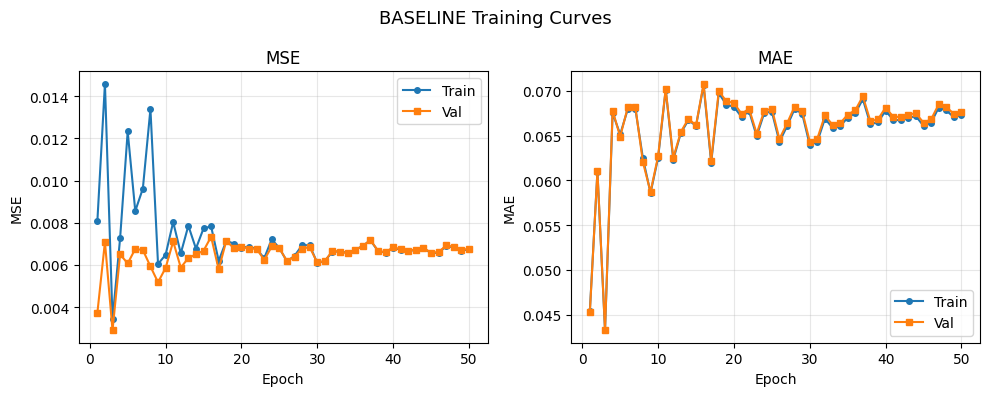

Curves saved → results/plots/baseline_training_curves.png


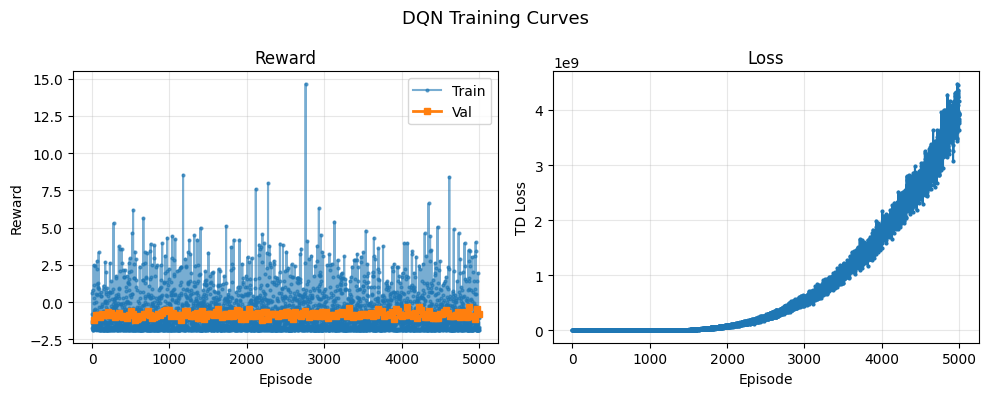

Curves saved → results/plots/dqn_training_curves.png


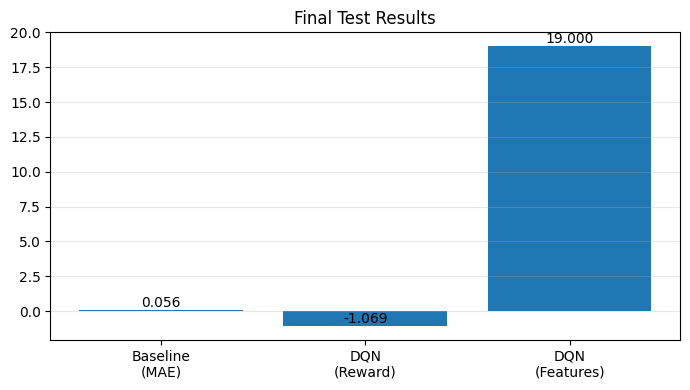

Comparison saved → results/plots/final_comparison.png


In [16]:
"""
visualization/visualize.py
────────────────────────────────
Creates side-by-side training curves from:

results/metrics/baseline_metrics.json
results/metrics/dqn_metrics.json
"""

import os
import json
import numpy as np
import matplotlib.pyplot as plt


# ── Utilities ──────────────────────────────────────────────────────────────────

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


# ── Baseline Plot ──────────────────────────────────────────────────────────────

def plot_baseline(metrics_path, save_dir):
    data = load_json(metrics_path)
    history = data["history"]

    epochs = [row["epoch"] for row in history]

    train_mse = [row["train_mse_norm"] for row in history]
    val_mse   = [row["val_mse_norm"]   for row in history]

    train_mae = [row["train_mae_norm"] for row in history]
    val_mae   = [row["val_mae_norm"]   for row in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle("BASELINE Training Curves", fontsize=13)

    # MSE
    ax1.plot(epochs, train_mse, marker="o", markersize=4, label="Train")
    ax1.plot(epochs, val_mse,   marker="s", markersize=4, label="Val")
    ax1.set(xlabel="Epoch", ylabel="MSE", title="MSE")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # MAE
    ax2.plot(epochs, train_mae, marker="o", markersize=4, label="Train")
    ax2.plot(epochs, val_mae,   marker="s", markersize=4, label="Val")
    ax2.set(xlabel="Epoch", ylabel="MAE", title="MAE")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, "baseline_training_curves.png")
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Curves saved → {path}")


# ── DQN Plot ───────────────────────────────────────────────────────────────────

def plot_dqn(metrics_path, save_dir):
    data = load_json(metrics_path)
    history = data["history"]

    episodes = [row["episode"] for row in history]

    train_reward = [row["train_reward"] for row in history]
    train_loss   = [row["train_loss"]   for row in history]

    val_eps = [row["episode"] for row in history if "val_avg_reward" in row]
    val_reward = [row["val_avg_reward"] for row in history if "val_avg_reward" in row]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle("DQN Training Curves", fontsize=13)

    # Reward
    ax1.plot(episodes, train_reward, alpha=0.6, label="Train", marker="o", markersize=2)
    if val_reward:
        ax1.plot(val_eps, val_reward, marker="s", markersize=4, linewidth=2, label="Val")
    ax1.set(xlabel="Episode", ylabel="Reward", title="Reward")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(episodes, train_loss, marker="o", markersize=2)
    ax2.set(xlabel="Episode", ylabel="TD Loss", title="Loss")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, "dqn_training_curves.png")
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Curves saved → {path}")


# ── Comparison Plot ────────────────────────────────────────────────────────────

def compare_final_results(baseline_path, dqn_path, save_dir):
    base = load_json(baseline_path)
    dqn  = load_json(dqn_path)

    baseline_mae = base["test_metrics"]["mae_real"]
    dqn_reward   = dqn["test_metrics"]["avg_reward"]
    dqn_features = dqn["test_metrics"]["avg_features"]

    fig, ax = plt.subplots(figsize=(7,4))

    labels = ["Baseline\n(MAE)", "DQN\n(Reward)", "DQN\n(Features)"]
    values = [baseline_mae, dqn_reward, dqn_features]

    bars = ax.bar(labels, values)
    ax.set_title("Final Test Results")
    ax.grid(True, axis="y", alpha=0.3)

    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h, f"{h:.3f}",
                ha="center", va="bottom")

    plt.tight_layout()

    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, "final_comparison.png")
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Comparison saved → {path}")


# ── Master Runner ──────────────────────────────────────────────────────────────

def plot_all(
    baseline_metrics="results/metrics/baseline_metrics.json",
    dqn_metrics="results/metrics/dqn_metrics.json",
    save_dir="results/plots"
):
    plot_baseline(baseline_metrics, save_dir)
    plot_dqn(dqn_metrics, save_dir)
    compare_final_results(baseline_metrics, dqn_metrics, save_dir)


if __name__ == "__main__":
    plot_all()